# 📊 Customer Complaint Classification using Machine Learning

This project focuses on classifying customer complaints into different categories using Natural Language Processing (NLP) and Machine Learning techniques.

The model is trained using TF-IDF vectorization and Logistic Regression to achieve high accuracy in multi-class text classification.

## 🎯 Objective

The objective of this project is to:

- Analyze customer complaint text data
- Classify complaints into predefined categories
- Apply NLP techniques like TF-IDF
- Train a machine learning model for prediction
- Evaluate model performance using standard metrics

## 📁 Dataset Description

The dataset used is the Consumer Complaint Dataset.

It contains:

- Customer complaint narratives (text data)
- Complaint categories (labels)

### Selected Features:
- **Text** → Complaint narrative
- **Category** → Complaint type

The dataset was cleaned by removing missing values and sampling a balanced subset for efficient training.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("complaints.csv")
df.head()

,Unnamed: 0,product_5,narrative,Product,Date received,Sub-product,Issue,Sub-issue,Company,State,Timely response?
0,234,Credit Reporting,Dear Possible Financial Inc you guyss aree rep...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Incorrect information on your report,Account information incorrect,Possible Financial Inc,MI,Yes
1,240,Debt Collection,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt collection,2024-07-27,I do not know,Threatened to contact someone or share informa...,Talked to a third-party about your debt,BlueChip Financial,TX,Yes
2,257,Credit Reporting,I been receiving alerts my information was fou...,Credit reporting or other personal consumer re...,2024-07-23,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,FC HoldCo LLC,SC,Yes
3,271,Credit Reporting,Subject : Dispute of Inaccurate Information on...,Credit reporting or other personal consumer re...,2024-07-27,Credit reporting,Improper use of your report,Reporting company used your report improperly,CORELOGIC INC,GA,Yes
4,276,Loans,They allowed me to use the account for about a...,"Payday loan, title loan, personal loan, or adv...",2024-07-26,Payday loan,Received a loan you didn't apply for,NaN,MoneyLion Inc.,PA,Yes


## 🧹 Data Preprocessing

The following preprocessing steps were performed:

- Selected relevant columns (text and category)
- Renamed columns for simplicity
- Removed missing values
- Created a balanced dataset by sampling equal records from each category

This ensures fair model training and avoids bias.

In [3]:
df = df[['narrative', 'product_5']]

# Rename for simplicity
df.columns = ['text', 'category']

df.head()

,text,category
0,Dear Possible Financial Inc you guyss aree rep...,Credit Reporting
1,"XXXX XXXX XXXX ( debt collector ), sent my boy...",Debt Collection
2,I been receiving alerts my information was fou...,Credit Reporting
3,Subject : Dispute of Inaccurate Information on...,Credit Reporting
4,They allowed me to use the account for about a...,Loans


In [4]:
df.dropna(inplace=True)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (2023066, 2)


In [5]:
# Take a balanced sample
df = df.groupby('category').apply(lambda x: x.sample(5000, random_state=42)).reset_index(drop=True)

print("New shape:", df.shape)

New shape: (25000, 2)


C:\Users\Chinmayi MH\AppData\Local\Temp\ipykernel_9416\3124595322.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('category').apply(lambda x: x.sample(5000, random_state=42)).reset_index(drop=True)


## 🔀 Train-Test Split

The dataset was divided into training and testing sets:

- 80% Training Data
- 20% Testing Data

This helps in evaluating the model on unseen data.

In [6]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (20000,)
Test size: (5000,)


## 🤖 Model Building

A machine learning pipeline was created using:

- **TF-IDF Vectorizer** for converting text into numerical features
- **Logistic Regression** for classification

### Why this model?
- Efficient for text classification
- Handles multi-class problems well
- Provides good accuracy with TF-IDF features

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1,2),
        stop_words='english'
    )),
    ('clf', LogisticRegression(max_iter=500))
])

## 🏋️ Model Training

The model was trained using the training dataset.

The pipeline automatically:
- Converts text into TF-IDF features
- Trains the Logistic Regression model

In [8]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', LogisticRegression(max_iter=500))])

In [9]:
y_pred = model.predict(X_test)

## 📊 Model Evaluation

The model was evaluated using:

- Accuracy Score
- Precision
- Recall
- F1-Score

### Result:
The model achieved an accuracy of approximately **85%**, indicating strong performance.

The classification report shows balanced performance across all categories.

In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8488

Classification Report:

                            precision    recall  f1-score   support

Bank Accounts and Services       0.88      0.89      0.89      1021
      Credit Card Services       0.84      0.81      0.82      1000
          Credit Reporting       0.82      0.86      0.84       985
           Debt Collection       0.82      0.81      0.81       989
                     Loans       0.89      0.87      0.88      1005

                  accuracy                           0.85      5000
                 macro avg       0.85      0.85      0.85      5000
              weighted avg       0.85      0.85      0.85      5000



## 📉 Confusion Matrix

A confusion matrix was plotted to visualize:

- Correct predictions
- Misclassifications

It helps in understanding how well the model distinguishes between different categories.

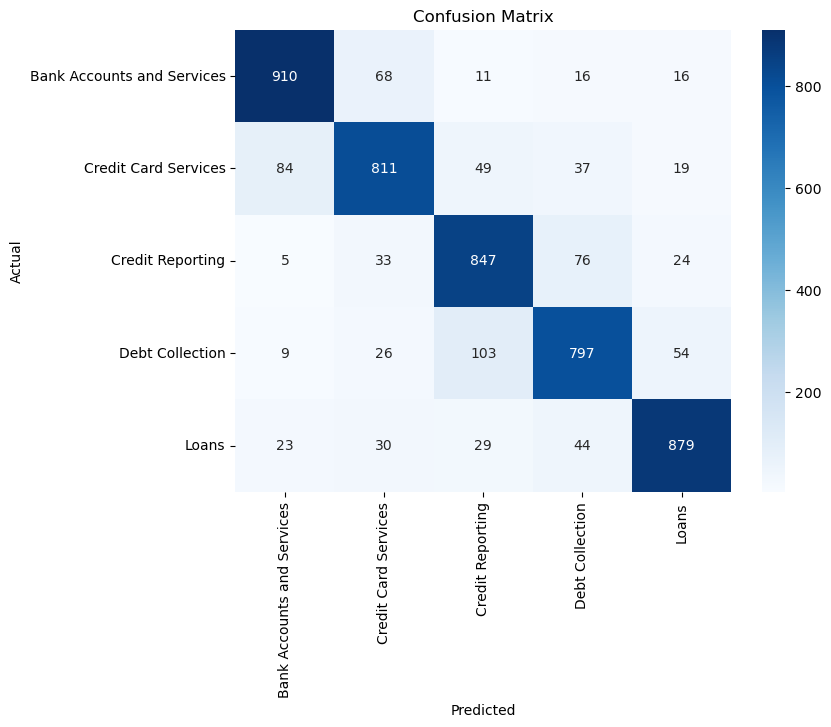

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that most predictions lie on the diagonal, indicating correct classification. 

Some misclassifications occur between similar categories like Credit Card Services and Bank Accounts, and between Debt Collection and Credit Reporting due to overlapping financial terminology.

Overall, the model performs well with minimal confusion across classes.

## 📊 Priority Distribution Analysis

The priority levels assigned to tickets show an imbalanced distribution:

- Most tickets fall under **Low Priority**
- Fewer tickets are classified as **High Priority**
- Medium priority represents general issues

This distribution reflects real-world scenarios, where critical issues are less frequent compared to normal inquiries.

The priority assignment is rule-based and depends on keyword detection in the ticket text.

In [12]:
def assign_priority(text):
    text = text.lower()
    
    high_keywords = ['fraud', 'unauthorized', 'scam', 'threat', 'urgent', 'hack']
    medium_keywords = ['delay', 'issue', 'error', 'problem', 'not working']
    
    if any(word in text for word in high_keywords):
        return "High"
    elif any(word in text for word in medium_keywords):
        return "Medium"
    else:
        return "Low"

df['priority'] = df['text'].apply(assign_priority)

df['priority'].value_counts()

priority
Low       14048
High       6171
Medium     4781
Name: count, dtype: int64

In [13]:
df[['text', 'category', 'priority']].head(10)

,text,category,priority
0,I attempted to take a loan out through a compa...,Bank Accounts and Services,Low
1,Sent 2 XXXX transactions from my XXXX exchange...,Bank Accounts and Services,Medium
2,I had an account with Coinbase Pro. I forgot m...,Bank Accounts and Services,Low
3,Chase bank closed my account without warning y...,Bank Accounts and Services,Low
4,In XX/XX/2020 I had an unapproved XXXX XXXX XX...,Bank Accounts and Services,Low
5,"I opened a checking account with Wells Fargo, ...",Bank Accounts and Services,High
6,I have had an extra20 account with Santander B...,Bank Accounts and Services,Medium
7,I attempted to use the USAA phone app to trans...,Bank Accounts and Services,Low
8,"On XX/XX/XXXX, I attempted to begin the proces...",Bank Accounts and Services,High
9,I have a XXXX TD Bank Credit Card the line of ...,Bank Accounts and Services,High


In [14]:
sample = ["My account was hacked and money was stolen"]

pred_category = model.predict(sample)
pred_priority = assign_priority(sample[0])

print("Category:", pred_category[0])
print("Priority:", pred_priority)

Category: Bank Accounts and Services
Priority: High


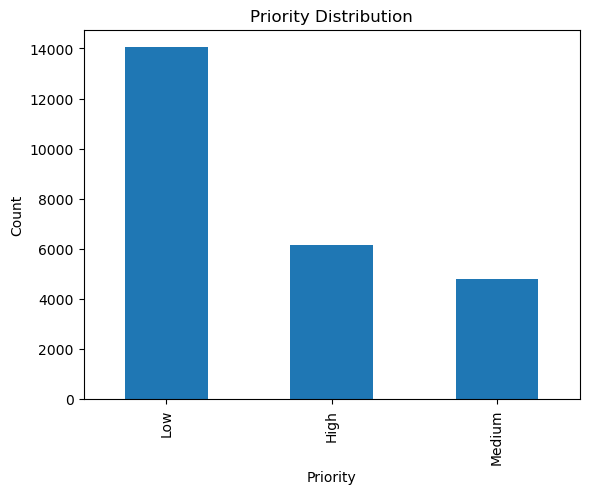

In [15]:
df['priority'].value_counts().plot(kind='bar')
plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

## ✅ Conclusion

The project successfully classified customer complaints using NLP and machine learning techniques.

Key insights:

- High accuracy achieved due to well-defined categories
- TF-IDF effectively captured text patterns
- Logistic Regression performed well for multi-class classification

This demonstrates the importance of data quality in machine learning tasks.

The model achieved an accuracy of approximately 85% using TF-IDF and Logistic Regression. 
The high performance is due to the clear distinction between categories in the dataset. 
Unlike previous datasets with overlapping labels, this dataset provided well-separated classes, allowing the model to learn meaningful patterns effectively.